# Trabalho 1

In this notebook we explore the motion models:
- Odometry Motion Model
- Velocity Motion Model
As well as the plot of a given gaussian distribution

### Gaussian Distribution Plot
The plot of the 2D gaussian will be a fundamental tool to visualize in upcoming implementations the estimates of robot's or feature's positions along with their respective uncertainities

### Odometry Motion Model:
The Odometry Motion Model, models the displacement as a sum of:
1. angular displacement ( i.e. in place rotation)
2. translational displacement
3. angular displacement ( second in place rotation)

### Velocity Motion Model
The Velocity Motion Motion assumes that the displacement of the robot follows a circular trajectory with a given angular speed $\omega$ and a linear speed $v$

### P.S.: About the contents
The verbose settings have been disabled. I will not use chatGPT or other AI assistents, to produce overly accurate and illustrative notebooks that redundantly explain the theory behind the plots and algorithms. I will be minimalistic and accurate. Most of the code is selfexplanatory and the understanding of the theory is intuitive and straightforward.

In [1]:
from robotics.geometry import Pose, Angle
from robotics.control import VelocityControl, OdometryControl
from robotics.robot import Robot
from robotics.distributions import ProbDistribution, GaussianDistribution

import matplotlib.pyplot as plt
import numpy as np

## Gaussian Distribution Plot
The plot of a 2D gaussian distribution with non-zero mean $(\mu_x, \mu_y)$, covariance $\sigma_{xy}$ and variance $(\sigma_x², \sigma_y²)$. More specifically, in this example:
$$\vec{\mu} = (\mu_x = 1.2, \mu_y = -3.2)$$

$$
\boldsymbol{\Sigma} = \begin{bmatrix}
\sigma_x^2 & \sigma_{xy} \\
\sigma_{xy} & \sigma_y^2
\end{bmatrix} = \begin{bmatrix}
1.4^2 & 1.7 \\
1.7 & 2.9^2
\end{bmatrix} = \begin{bmatrix}
1.96 & 1.7 \\
1.7 & 8.41
\end{bmatrix}
$$

The mathematical expression of the distribution is then:
$$
\mathcal{N}(\mathbf{x} | \boldsymbol{\mu}, \boldsymbol{\Sigma}) = \frac{1}{(2\pi)^{n/2} |\boldsymbol{\Sigma}|^{1/2}} \exp\left(-\frac{1}{2} (\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})\right)
$$


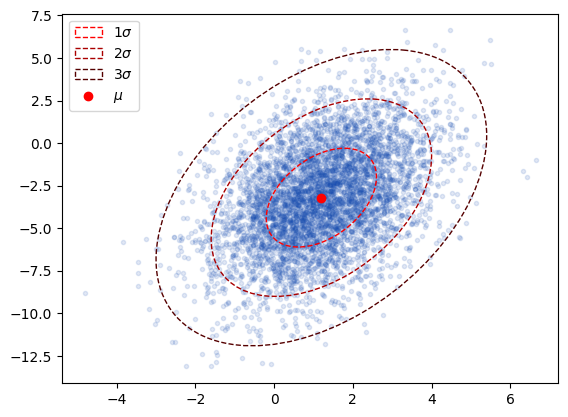

In [2]:
mu_x = 1.2
mu_y = -3.2

sigma_x  = 1.4
sigma_y  = 2.9
sigma_xy = 1.7

mu = np.array([mu_x, mu_y])
sigma = np.array([[sigma_x**2, sigma_xy],[sigma_xy, sigma_y**2]])

f = plt.figure()
ax = f.gca()

n_samples = 5000

for _ in range(n_samples):
    sample = np.random.multivariate_normal(mu, sigma)
    ax.scatter(sample[0], sample[1], color="#184eb321", marker='.')

    
GaussianDistribution.plotGaussian2D(ax, mu.reshape((2,1)), sigma)

## Odometry Motion Model
As briefly explained above, the odometry motion is modeled by three subsequent motions. A first rotation, a translation and a final rotation. Given two poses $\vec{x}_{\text{start}}$ and $\vec{x}_{\text{end}}$ these parameters can be estimated and compared to the actual control input applied to compute the most likely position after the control input.

### Probabilistic Model
Given a hypothesis and an actual command, the likelyhood of that hypothesis, w.r.t. the actual input under the effect of noise (modeled by the $\alpha$s) can be computed as a probability composed of three factors, modelling each of the three aspects respectively of the movements: intial rotation, translation, final rotation.

### Sampling Model
Similarly a given distribution can be sampled various times to determine the most likely position after the applied control based on hit count in a given region of interest.

---

These two approaches are plotted below to illustrate the differences and similarities

In [3]:
class Odometry:
    def __init__(self, pos_start: Pose, pos_end: Pose):
        self.pos_s = pos_start
        self.pos_e = pos_end

    @property
    def dy(self): 
        return self.pos_e.y - self.pos_s.y
    
    @property
    def dx(self): 
        return self.pos_e.x - self.pos_s.x

    @property
    def  dth_1(self):
        return Angle.atan2(self.dy, self.dx) - self.pos_s.th

    @property
    def dr(self):
        return np.sqrt(self.dx**2 + self.dy**2)

    @property
    def dth_2(self):
        return self.pos_e.th - self.pos_s.th - self.dth_1

    @staticmethod
    def motionModel(hypothesis: 'Odometry', actual: 'Odometry', distribution: ProbDistribution = GaussianDistribution, alphas: tuple[float, float, float, float, float, float] = (0.1, 0.1, 0.1, 0.1, 0.1, 0.1)):
        a1, a2, a3, a4, a5, a6 = alphas

        p1 = distribution(a1 * np.abs(actual.dth_1) + a2 * actual.dr).prob((actual.dth_1 - hypothesis.dth_1).rad)
        p2 = distribution(a3 * np.abs(actual.dth_1) + a4 * (np.abs(actual.dth_1) + np.abs(actual.dth_2))).prob(actual.dr - hypothesis.dr)
        p3 = distribution(a5 * np.abs(actual.dth_2) + a6 * actual.dr).prob((actual.dth_2 - hypothesis.dth_2).rad)

        return p1 * p2 * p3

    @staticmethod
    def sampleMotionModel(x0: Pose, odometry: 'Odometry', distribution: ProbDistribution = GaussianDistribution, alphas: tuple[float, float, float, float, float, float] = (0.1, 0.1, 0.1, 0.1, 0.1, 0.1)):
        a1, a2, a3, a4, a5, a6 = alphas

        dth_1_h = (odometry.dth_1 - Angle(distribution(a1 * odometry.dth_1.rad ** 2 + a2 * odometry.dr **2).sample()))
        dr_h    = odometry.dr - distribution(a3 * odometry.dr ** 2 + a4 * (odometry.dth_1 + odometry.dth_2).rad).sample()
        dth_2_h = (odometry.dth_2 - Angle(distribution(a5 * odometry.dth_2.rad ** 2 + a6 * odometry.dr **2).sample()))

        return Pose(
            x0.x + dr_h * (x0.th + dth_1_h).cos,
            x0.y + dr_h * (x0.th + dth_1_h).sin,
            x0.th + dth_1_h + dth_2_h
        )


In [4]:
def plotOdometryProbabilityDistribution(
        ax: plt.Axes, 
        x0: Pose = Pose(0., 0., 0.), 
        u: OdometryControl = OdometryControl(Angle(0.), 1., Angle(0.)), 
        alphas: tuple[float, float, float, float, float, float] = (0.1, 0.1, 0.1, 0.1, 0.1, 0.1), 
        resolution: float = 0.08, 
        x_interval: list[float, float] = [-5., 5.], 
        y_interval: list[float, float] = [-5., 5.]
    ):
    # Initialize robot
    r = Robot(x0)

    #Plot Initial Position
    r.draw(ax, alt_label="Initial Position")

    #Apply Control
    _ = r.applyControl(u)
    r.draw(ax, linestyles=['--', '--'], alt_label= "Actual Position")

    #Draw probability distribution
    nx = int((x_interval[1] -  x_interval[0] + resolution) / resolution)
    ny = int((y_interval[1] -  y_interval[0] + resolution) / resolution)

    probability_distribution =  np.zeros((ny, nx))
    a = 0
    for x_idx, x in enumerate(np.linspace(x_interval[0], x_interval[1], num = nx)):
        for y_idx, y in enumerate(np.linspace(y_interval[0], y_interval[1], num = ny)):
            hypothesis = Odometry(x0, Pose(x, y, r.pos.th))
            actual = Odometry(x0, r.pos)
            
            probability_distribution[y_idx, x_idx] = Odometry.motionModel(hypothesis, actual, alphas=alphas)

    ax.imshow(probability_distribution, cmap='Blues', extent=[x_interval[0], x_interval[1], y_interval[0], y_interval[1]], origin='lower')

def plotOdometrySampleDistribution(
        ax: plt.Axes, 
        x0: Pose = Pose(0., 0., 0.), 
        u: OdometryControl = OdometryControl(Angle(0.), 1., Angle(0.)), 
        alphas: tuple[float, float, float, float, float, float] = (0.1, 0.1, 0.1, 0.1, 0.1, 0.1), 
        n_samples = 200,
        x_interval: list[float, float] = [-5., 5.], 
        y_interval: list[float, float] = [-5., 5.]
    ):
    # Initialize robot
    r = Robot(x0)
    
    #Plot Initial Position
    r.draw(ax, alt_label="Initial Position")

    #Apply Control
    _ = r.applyControl(u)

    odo = Odometry(x0, r.pos)
    for i in range(n_samples):

        sample = Odometry.sampleMotionModel(x0, odo, alphas=alphas)
        ax.scatter(sample.x, sample.y, color="#184eb321", marker='.')

    r.draw(ax, linestyles=['--', '--'], alt_label= "Actual Position")
    
    ax.set_xlim(x_interval[0], x_interval[1])
    ax.set_ylim(y_interval[0], y_interval[1])

    


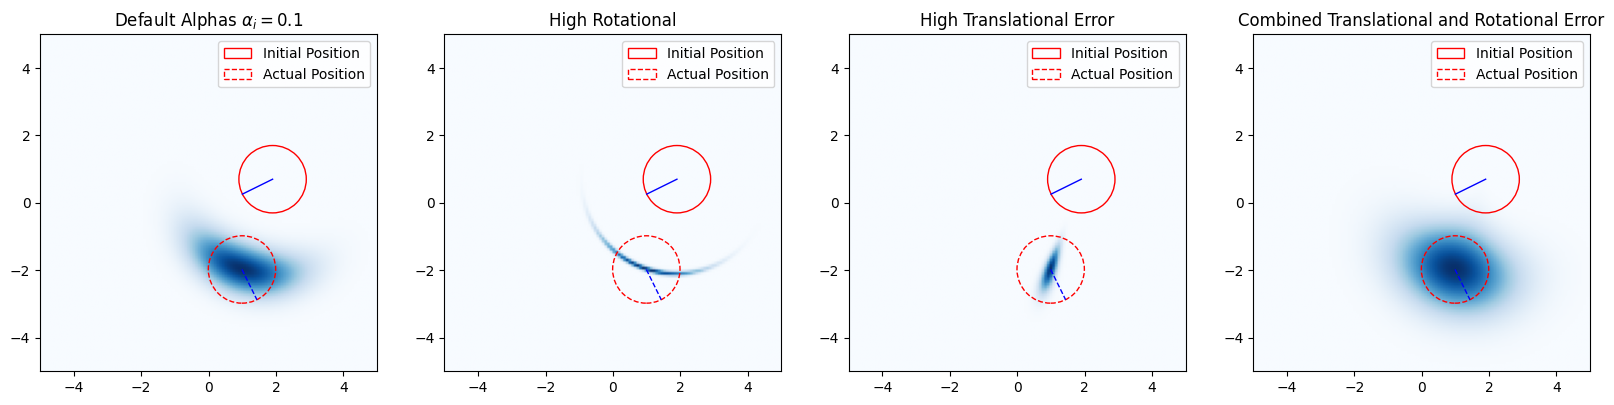

In [5]:
#Initial Position and Control Input:
x0 = Pose(1.9, 0.7, Angle(3.6))
u = OdometryControl(Angle(np.pi / 4), 2*np.sqrt(2), Angle(np.pi / 4))

#Figure with subplot

f = plt.figure(figsize=(20,5))

ax1 = plt.subplot(1,4, 1)
ax1.set_title("Default Alphas $\\alpha_i = 0.1$")
plotOdometryProbabilityDistribution(ax1, x0, u)

ax2 = plt.subplot(1,4, 2)
ax2.set_title("High Rotational")
plotOdometryProbabilityDistribution(ax2, x0, u, alphas=(0.1, 0.1, 0.001, 0.001, 0.1, 0.1))

ax3 = plt.subplot(1,4, 3)
ax3.set_title("High Translational Error")
plotOdometryProbabilityDistribution(ax3, x0, u, alphas=(0.001, 0.001, 0.1, 0.1, 0.001, 0.001))

ax4 = plt.subplot(1,4, 4)
ax4.set_title("Combined Translational and Rotational Error")
plotOdometryProbabilityDistribution(ax4, x0, u, alphas=(0.3, 0.0001, 0.8, 0.05, 0.01, 0.2))


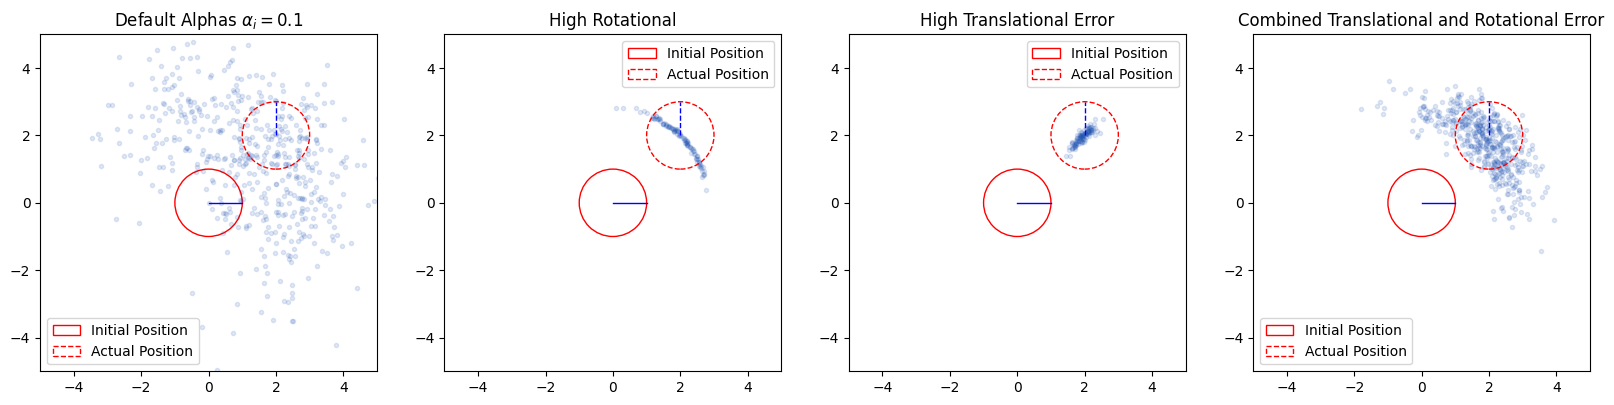

In [6]:
#Initial Position and Control Input:
x0 = Pose(0., 0., 0.)
u = OdometryControl(Angle(np.pi / 4), 2 * np.sqrt(2), Angle(np.pi / 4))

#Figure with subplot

f = plt.figure(figsize=(20,5))

ax1 = plt.subplot(1,4, 1)
ax1.set_title("Default Alphas $\\alpha_i = 0.1$")
plotOdometrySampleDistribution(ax1, x0, u, n_samples=500)

ax2 = plt.subplot(1,4, 2)
ax2.set_title("High Rotational")
plotOdometrySampleDistribution(ax2, x0, u, alphas=(0.01, 0.01, 0.0001, 0.0001, 0.01, 0.01), n_samples=100)

ax3 = plt.subplot(1,4, 3)
ax3.set_title("High Translational Error")
plotOdometrySampleDistribution(ax3, x0, u, alphas=(0.0001, 0.0001, 0.01, 0.01, 0.0001, 0.0001), n_samples=100)

ax4 = plt.subplot(1,4, 4)
ax4.set_title("Combined Translational and Rotational Error")
plotOdometrySampleDistribution(ax4, x0, u, alphas=(0.3, 0.001, 0.02, 0.005, 0.01, 0.02), n_samples=500)

## Velocity / Circular Motion Model
The velocity motion model, in contrast to the odometry motion model, describes movement as a circular motion with velociteis $v [m/s]$ and $\omega [\text{rad}/s]$ over a given time interval $\Delta t$.

### Probabilistic Model
Similarly as with the Odometry's probabilistic model, a hypothesis is generated for a target location and checked against the actual applied command to compute the likelyhood of the robots position at given hypothetical location.

### Sample Model
Exactly as with the Odometry's sample model, a sample can be generated and a population of samples will indicate the most likely location.

---
Note: the velocity model has two flaws that need to be taken into account:

1. It always finds the shortest path to the target point.
2. It does not take into account the initial heading direction of the robot.

These two points require special attention as a fragmented plot would otherwise be produced by computing the probabilities. Indeed the angle of rotation produces only $(v, \omega)$ pairs that are of the same sign, since:

$$\omega = \Delta\theta_{\text{rot}} \cdot \Delta t$$

and 

$$v = \omega \cdot r_{\text{rot}}$$

To better explain the issue let's consider a robot positioned at $\vec{x_0} = (0, 0, 0°)$ moving forward.

If the hypothesis lays in the II quadrant, the $\Delta\theta_{\text{rot}}$ computed by the raw algorithm will yield a negative value, as it is the shortest path to the point on the given circle. Howecer, this would assume a backwards motion with $(v, \omega)$ both negative. But for this model we assume a forward motion, so we need to adjust $\Delta\theta_{\text{rot}} = \Delta\theta_{\text{rot}} + 2\pi$

If the hypothesis lays in the III quadrant we have the issue that the $\Delta\theta_{\text{rot}}$ is greater than 0, which yields the same results as in the I quadrant, if no corrective measures are applied. Indeed, also in this case we have to enforce the assumption of the robot moving forward. this means that to reach the point on the circle given these initial conditions, the only way to do so without moving backwards is to have a negative $\omega$ and a positive $v$. 

Finally, if the hypothesis lays in the IV quadrant we have a similar problem like in the II quadrant, i.e. that the $\Delta\theta_{\text{rot}}$ is less than zero. Leading to the same conflict, that a backwards motion with $(v, \omega)$ both negative would be modeled.

At this point we can notice that in quadrants I and II (or more generally on the left hand side of the robot) the point on the circle, under the initial assumptions, can only be reached if we enforce a positive pair of velocities $(v, \omega)$. For this to be computed properly the value of $\Delta\theta_{\text{rot}}$ must be adjusted by adding $2\pi$ when $\omega$ would results in a negative value.\
Similarly, for the points in the quadrants III and IV (or more generally on the right hand side of the robot) the point on the circle, under the initial assumptions, can only be reached if we enforce a positive $v$ and a negative $\omega$. For this to be computed properly the value of $\Delta\theta_{\text{rot}}$ must be adjusted by subtracting $2\pi$ when $\omega$ would results in a positive value, and the sign of must be flipped resulting in the computation of $v = - \omega \cdot r_{\text{rot}}$.

In [7]:
class CircularMotion:
    def __init__(self, x_start: Pose, x_end: Pose, dt: float):
        self.x0 = x_start
        self.x1 = x_end
        self.dt = dt

    @property
    def dx(self):
        return self.x1.x - self.x0.x

    @property
    def dy(self):
        return self.x1.y - self.x0.y
    
    @property
    def dth(self):
        return self.x1.th - self.x0.th

    @property
    def sum_x(self):
        return self.x1.x + self.x0.x

    @property
    def sum_y(self):
        return self.x1.y + self.x0.y
    
    @property
    def mu(self):
        num = self.dx * x0.th.cos + self.dy * x0.th.sin 
        den = 2 * (self.dy * x0.th.cos - self.dx * x0.th.sin)

        return num / den 

    @property
    def c_rot(self):
        c_x = self.sum_x / 2 - self.mu * self.dy
        c_y = self.sum_y / 2 + self.mu * self.dx

        return (c_x, c_y)

    @property
    def r_rot(self):
        c_x, c_y = self.c_rot

        return np.sqrt((self.x0.x - c_x)**2 + (self.x0.y - c_y)**2)

    @property
    def dth_rot(self):
        c_x, c_y = self.c_rot

        cos_a = self.x1.x - c_x
        sin_a = self.x1.y - c_y
        cos_b = self.x0.x - c_x
        sin_b = self.x0.y - c_y
        dth_rot = Angle.atan2(sin_a * cos_b - cos_a * sin_b, cos_a * cos_b + sin_a * sin_b)

        return dth_rot
    
    @property
    def w(self):
        w = self.dth_rot.rad / self.dt

        y_local = -self.dx * self.x0.th.sin + self.dy * self.x0.th.cos
        
        if y_local > 0:
            # Target is to the left
            if w < 0: 
                w = ( 2 * np.pi + self.dth_rot.rad ) / self.dt
        elif y_local < 0:
            # Target is to the right
            if w > 0: 
                w = (self.dth_rot.rad - 2 * np.pi) / self.dt
        else:
            # Target is directly ahead or behind
            pass

        return w

    @property
    def v(self):
        v = self.w * self.r_rot

        y_local = -self.dx * self.x0.th.sin + self.dy * self.x0.th.cos
                
        if y_local > 0:
            # Target is to the left
            pass
        elif y_local < 0:
            # Target is to the right
            v = - self.w * self.r_rot
        else:
            # Target is directly ahead or behind
            pass
        
        return v

    @property
    def gamma(self):
        return self.dth.rad / self.dt - self.w

    @staticmethod
    def motionModel(hypothesis: 'CircularMotion', actual: VelocityControl, distribution: ProbDistribution = GaussianDistribution, alphas: tuple[float, float, float, float, float, float] = (0.1, 0.1, 0.1, 0.1, 0.1, 0.1)):
        a1, a2, a3, a4, a5, a6 = alphas
        p1 = distribution(a1 * actual.v **2 + a2 * actual.w **2).prob(actual.v - hypothesis.v)
        p2 = distribution(a3 * actual.v **2 + a4 * actual.w **2).prob(actual.w - hypothesis.w)
        p3 = distribution(a5 * actual.v **2 + a6 * actual.w **2).prob(hypothesis.gamma)

        return p1 * p2 * p3

    @staticmethod
    def sampleMotionModel(x0: Pose, u: VelocityControl, distribution: ProbDistribution = GaussianDistribution, alphas: tuple[float, float, float, float, float, float] = (0.1, 0.1, 0.1, 0.1, 0.1, 0.1)):
        a1, a2, a3, a4, a5, a6 = alphas

        v = u.v + distribution(a1 * u.v **2 + a2 * u.w **2).sample()
        w = u.w + distribution(a3 * u.v **2 + a4 * u.w **2).sample()
        gamma = distribution(a5 * u.v **2 + a6 * u.w **2).sample()

        r_rot = v / w
        th_rot = x0.th + Angle(w * u.dt)

        return Pose(
            x0.x - r_rot * (x0.th.sin - th_rot.sin),
            x0.y + r_rot * (x0.th.cos - th_rot.cos),
            th_rot + Angle(gamma * u.dt)
        )

     

In [8]:
def plotCircularMotionProbabilityDistribution(
        ax: plt.Axes, 
        x0: Pose = Pose(0., 0., 0.), 
        u: VelocityControl = VelocityControl(0.1, 1., 0.1), 
        alphas: tuple[float, float, float, float, float, float] = (1e-2, 1e-2, 1e-2, 1e-2, 1e-2, 1e-2), 
        resolution: float = 0.08, 
        x_interval: list[float, float] = [-5., 5.], 
        y_interval: list[float, float] = [-5., 5.]
    ):
    # Initialize robot
    r = Robot(x0)

    #Plot Initial Position
    r.draw(ax, alt_label="Initial Position")

    #Apply Control
    _ = r.applyControl(u)
    r.draw(ax, linestyles=['--', '--'], alt_label= "Actual Position")

    #Draw probability distribution
    nx = int((x_interval[1] -  x_interval[0] + resolution) / resolution)
    ny = int((y_interval[1] -  y_interval[0] + resolution) / resolution)

    probability_distribution =  np.zeros((ny, nx))

    for x_idx, x in enumerate(np.linspace(x_interval[0], x_interval[1], num = nx)):
        for y_idx, y in enumerate(np.linspace(y_interval[0], y_interval[1], num = ny)):
            hypothesis = CircularMotion(x0, Pose(x, y, r.pos.th), u.dt)

            probability_distribution[y_idx, x_idx] = CircularMotion.motionModel(hypothesis, u, alphas=alphas)

    ax.imshow(probability_distribution, cmap='Blues', extent=[x_interval[0], x_interval[1], y_interval[0], y_interval[1]], origin='lower')

def plotCircularMotionSampleDistribution(
        ax: plt.Axes, 
        x0: Pose = Pose(0., 0., 0.), 
        u: OdometryControl = OdometryControl(Angle(0.), 1., Angle(0.)), 
        alphas: tuple[float, float, float, float, float, float] = (0.01, 0.01, 0.01, 0.01, 0.01, 0.01), 
        n_samples = 200,
        x_interval: list[float, float] = [-5., 5.], 
        y_interval: list[float, float] = [-5., 5.]
    ):
    # Initialize robot
    r = Robot(x0)
    
    #Plot Initial Position
    r.draw(ax, alt_label="Initial Position")

    #Apply Control
    _ = r.applyControl(u)

    for i in range(n_samples):
        sample = CircularMotion.sampleMotionModel(x0, u, alphas=alphas)
        ax.scatter(sample.x, sample.y, color="#184eb321", marker='.')

    r.draw(ax, linestyles=['--', '--'], alt_label= "Actual Position")
    
    ax.set_xlim(x_interval[0], x_interval[1])
    ax.set_ylim(y_interval[0], y_interval[1])

    


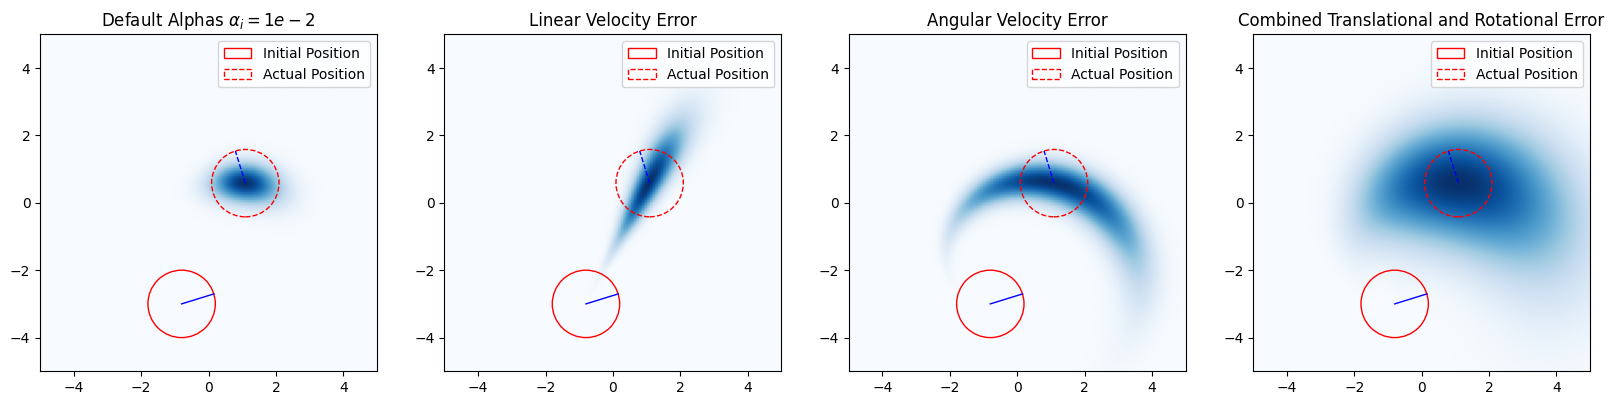

In [9]:
#Initial Position and Control Input:
x0 = Pose(-0.8, -3., Angle(0.3))
u = VelocityControl(1.5, np.pi / 2 / 3, 3)

#Figure with subplot

f = plt.figure(figsize=(20,5))

ax1 = plt.subplot(1,4, 1)
ax1.set_title("Default Alphas $\\alpha_i = 1e-2$")
plotCircularMotionProbabilityDistribution(ax1, x0, u)

ax2 = plt.subplot(1,4, 2)
ax2.set_title("Linear Velocity Error")
plotCircularMotionProbabilityDistribution(ax2, x0, u, alphas=(1e-1, 1e-1, 1e-3, 1e-3, 1e-2, 1e-2))

ax3 = plt.subplot(1,4, 3)
ax3.set_title("Angular Velocity Error")
plotCircularMotionProbabilityDistribution(ax3, x0, u, alphas=(1e-2, 1e-2, 15e-2, 1e-2, 1e-1, 1e-1))

ax4 = plt.subplot(1,4, 4)
ax4.set_title("Combined Translational and Rotational Error")
plotCircularMotionProbabilityDistribution(ax4, x0, u, alphas=(1e-1, 1e-1, 15e-2, 1e-2, 1e-1, 1e-1))


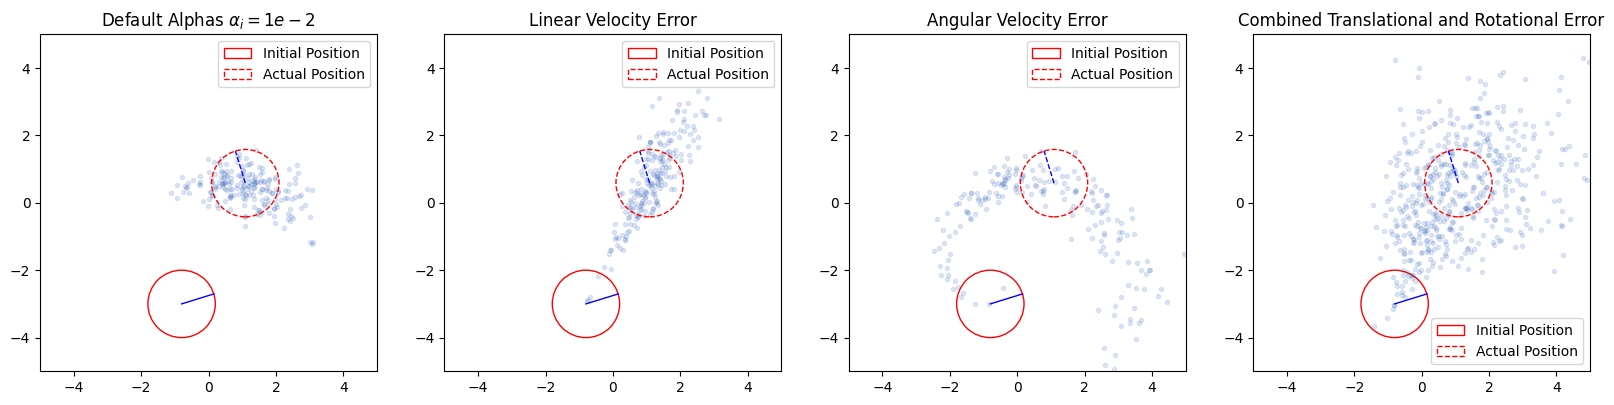

In [11]:
#Initial Position and Control Input:
x0 = Pose(-0.8, -3., Angle(0.3))
u = VelocityControl(1.5, np.pi / 2 / 3, 3)

#Figure with subplot

f = plt.figure(figsize=(20,5))

ax1 = plt.subplot(1,4, 1)
ax1.set_title("Default Alphas $\\alpha_i = 1e-2$")
plotCircularMotionSampleDistribution(ax1, x0, u)

ax2 = plt.subplot(1,4, 2)
ax2.set_title("Linear Velocity Error")
plotCircularMotionSampleDistribution(ax2, x0, u, alphas=(1e-1, 1e-1, 1e-3, 1e-3, 1e-2, 1e-2))

ax3 = plt.subplot(1,4, 3)
ax3.set_title("Angular Velocity Error")
plotCircularMotionSampleDistribution(ax3, x0, u, alphas=(1e-2, 1e-2, 15e-2, 1e-2, 1e-1, 1e-1))

ax4 = plt.subplot(1,4, 4)
ax4.set_title("Combined Translational and Rotational Error")
plotCircularMotionSampleDistribution(ax4, x0, u, alphas=(15e-2, 15e-2, 15e-3, 1e-2, 15e-2, 15e-2), n_samples=500)
